# Tutorial 2D Classification

> This tutorial provides a comprehensive, step-by-step guide to using bioMONAI for 2D microscopy image classification tasks. 

In particular, we'll employ the publicly available BloodMNIST dataset. The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes.

In [ ]:
#| default_exp tutorial_1

### Setup imports

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.losses import *
from bioMONAI.metrics import *
from bioMONAI.datasets import download_medmnist

from monai.utils import set_determinism
from fastai.vision.all import *

### Set deterministic training for reproducibility

In [ ]:
set_determinism(0)

### Create a Device object
Device type: "cuda" or "cpu"

In [ ]:
device = get_device()
print(device)

cuda


### Download Dataset
> The bioMONAI platform offers a dedicated functionality for downloading MedMNIST datasets, accesible via the "download_medmnist" function. 

To initiate the download, simply provide the name of the desired dataset ('bloodmnist', in this case) and the output directory in which you would like the data saved. If this directory does not already exist, it will be automatically created. If the "download_only" argument is set to "True", no processing will be applied to the data.

In [ ]:
data_path = Path('../_data/medmnist_data/bloodmnist/')
info = download_medmnist('bloodmnist', data_path, download_only=True)
info

100%|██████████| 35461855/35461855 [00:07<00:00, 4987584.85it/s]


Using downloaded and verified file: ../_data/medmnist_data/bloodmnist/bloodmnist.npz
Using downloaded and verified file: ../_data/medmnist_data/bloodmnist/bloodmnist.npz
Saving training images to ../_data/medmnist_data/bloodmnist...


100%|██████████| 11959/11959 [01:15<00:00, 158.73it/s]


Saving validation images to ../_data/medmnist_data/bloodmnist...


100%|██████████| 1712/1712 [00:10<00:00, 156.51it/s]


Saving test images to ../_data/medmnist_data/bloodmnist...


100%|██████████| 3421/3421 [00:21<00:00, 159.91it/s]

Removed bloodmnist.npz
Datasets downloaded to ../_data/medmnist_data/bloodmnist
Dataset info for 'bloodmnist': {'python_class': 'BloodMNIST', 'description': 'The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.', 'url': 'https://zenodo.org/records/10519652/files/bloodmnist.npz?download=1', 'MD5': '7053d0359d879ad8a5505303e11de1dc', 'url_64': 'https://zenodo.org/records/10519652/files/bloodmnist_64.npz?download=1', 'MD5_64': '2b94928a2ae4916078ca51e05b6b800b', 'url_128': 'https://zenodo.org/records/10519652/files/bloodmnist_128.npz?download=1', 'MD5_128

{'python_class': 'BloodMNIST',
 'description': 'The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/bloodmnist.npz?download=1',
 'MD5': '7053d0359d879ad8a5505303e11de1dc',
 'url_64': 'https://zenodo.org/records/10519652/files/bloodmnist_64.npz?download=1',
 'MD5_64': '2b94928a2ae4916078ca51e05b6b800b',
 'url_128': 'https://zenodo.org/records/10519652/files/bloodmnist_128.npz?download=1',
 'MD5_128': 'adace1e0ed228fccda1f39692059dd4c',
 'url_224': 'https://zenodo.org/records/10519652/files/bloodmnist

### Create Dataloader

 Once the data has been downloaded, we generates instances for train/validation from the dataset stored in the "data_path" directory. Thus, we create a DataLoader using the method "BioDataLoaders.from_source" configured with the arguments in "data_ops". , the "show_summary" argument is set to "True" in this case, which will result in a summary being printed after its creation.

 The arguments to the 'BioDataLoaders' are: 
 - 'blocks':    list of input/output block types. For this classification task, the "CategoryBlock" is used.
 - 'get_items': by default the "get_image_files" function, which get image files recursively.
 - 'get_y':     "parent_label" to get the corresponding label with the parent folder name.
 - 'splitter':  "GrandparentSplitter" to split items from the train/valid paths. 
 - 'item_tfms': transforms applied to the items.
 - 'bs':        batch size set to 6.
 

In [ ]:
bs, size = 6, 128

path_train = data_path/'train'
path_val = data_path/'val'

data_ops = {
    'blocks':       (BioImageBlock(cls=BioImageMulti), CategoryBlock()),
    'get_items':    get_image_files,
    'get_y':        parent_label,
    'splitter':     GrandparentSplitter(),
    'item_tfms':    [ScaleIntensity(min=0.0, max=1.0), RandCrop2D(size), RandRot90(prob=0.5), RandFlip(prob=0.75)],
    'bs': bs,
}

data = BioDataLoaders.from_source(
    data_path, 
    show_summary=True,
    **data_ops,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

Setting-up type transforms pipelines
Found 17092 items
2 datasets of sizes 13674,3418
Setting up Pipeline: BioImageMulti.create -> Tensor2BioImage -- {}
Setting up Pipeline: parent_label -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

Building one sample
  Pipeline: BioImageMulti.create -> Tensor2BioImage -- {}
    starting from
      ../_data/medmnist_data/bloodmnist/train/3/train_1091.png
    applying BioImageMulti.create gives
      BioImageMulti of size 3x28x28
    applying Tensor2BioImage -- {} gives
      BioImageMulti of size 3x28x28
  Pipeline: parent_label -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}
    starting from
      ../_data/medmnist_data/bloodmnist/train/3/train_1091.png
    applying parent_label gives
      3
    applying Categorize -- {'vocab': None, 'sort': True, 'add_na': False} gives
      TensorCategory(3)

Final sample: (BioImageMulti([[[236., 230., 211.,  ..., 255., 255., 255.],
         [245., 241., 222.,  ..., 255., 255., 

### Data Visualization
The "show_batch" function is used to display a batch of 4 input images and their corresponding targets. 

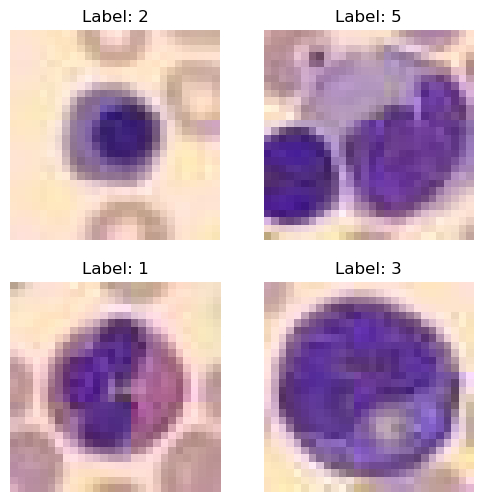

In [ ]:
data.show_batch(max_n=4)

### Configure the model

In [ ]:
model = resnet18

loss = CrossEntropyLossFlat()
metrics = accuracy

trainer = visionTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=True)

Sequential (Input shape: 6 x 3 x 28 x 28)
Layer (type)         Output Shape         Param #    Trainable 
                     6 x 64 x 14 x 14    
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     6 x 64 x 7 x 7      
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                         

### Train the model
Call to the "fit" method, specifying the number of training epochs.

epoch,train_loss,valid_loss,accuracy,time
0,1.419444,3.376241,0.602399,01:58
1,1.079784,2.099452,0.700995,02:00


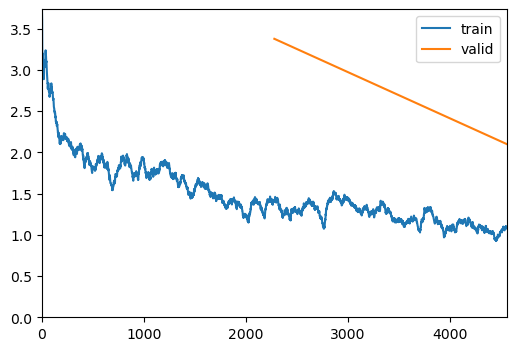

In [ ]:
trainer.fit(2)

### Inspection of the results

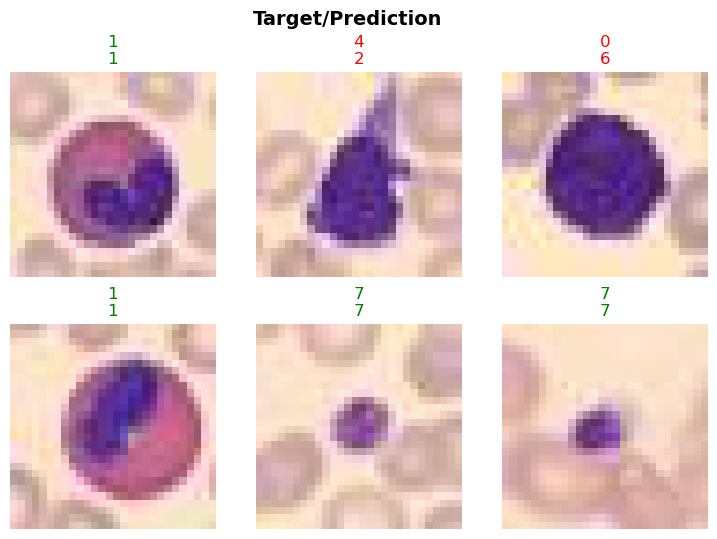

In [ ]:
trainer.show_results()

### Save the model
You can optionally save the trained model.

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!